In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds

In [2]:
X_train, y_train = tfds.as_numpy(
    tfds.load("rock_paper_scissors", split="train", batch_size=-1, as_supervised=True)
)

In [3]:
X_train.shape

(2520, 300, 300, 3)

In [4]:
y_train.shape

(2520,)

In [5]:
np.unique(y_train)  # valeurs existantes pour y_train

array([0, 1, 2])

In [6]:
np.bincount(y_train)  # combien de chaque

array([840, 840, 840])

Les classes 0, 1, 2 sont bien équilibrées. 840 images de chaque.

In [7]:
X_test, y_test = tfds.as_numpy(
    tfds.load("rock_paper_scissors", split="test", batch_size=-1, as_supervised=True)
)

print("test :", X_test.shape, X_test.dtype)

test : (372, 300, 300, 3) uint8


In [8]:
np.unique(y_test)  # valeurs existantes pour y_test

array([0, 1, 2])

In [9]:
print("train :", np.bincount(y_train))
print("test  :", np.bincount(y_test))

train : [840 840 840]
test  : [124 124 124]


372 images, 124 par classe. C'est peu !

In [10]:
baseline_triviale = np.bincount(y_test).max() / len(y_test)
print(f"Baseline (classe majoritaire) : {baseline_triviale:.1%}")

Baseline (classe majoritaire) : 33.3%


- 33 %	le modèle n'a rien appris
- 59 % 	il a appris quelque chose, mais peu
- 95 % 	il a vraiment appris

Équilibre des classes. Le jeu est parfaitement équilibré (840 par classe en entraînement, 124 en test). L'accuracy est donc une métrique légitime, et la baseline triviale à battre est de 33,3 %.

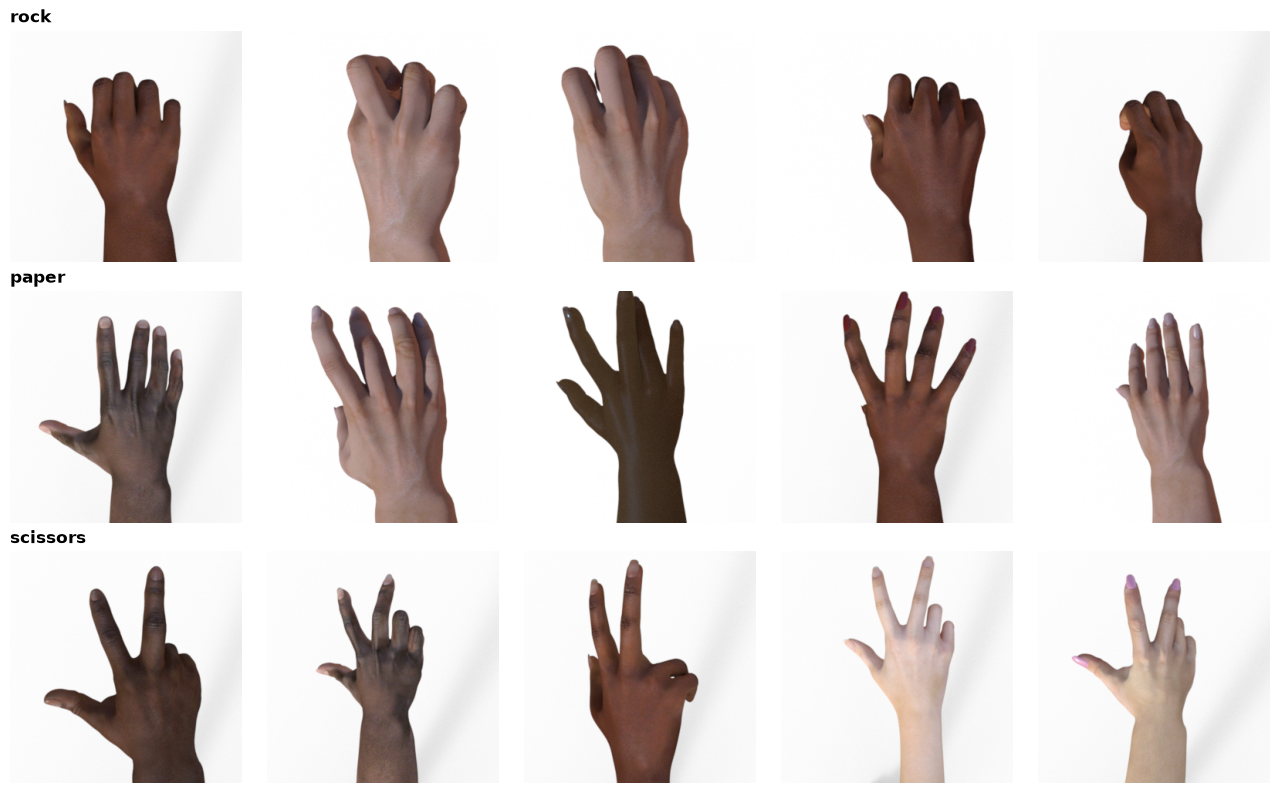

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
noms = ["rock", "paper", "scissors"]

for ligne in range(3):
    indices = np.flatnonzero(y_train == ligne)[:5]
    for colonne, idx in enumerate(indices):
        axes[ligne, colonne].imshow(X_train[idx])
        axes[ligne, colonne].axis("off")
    axes[ligne, 0].set_ylabel(noms[ligne])
    axes[ligne, 0].set_title(noms[ligne], loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

Les images sont des rendus 3D : fond blanc uniforme, éclairage constant, cadrage stable, aucun bruit de capteur. Idem pour le jeu de test. 
L'accuracy mesurée dessus ne prédit pas la performance sur des photos de webcam.

### Stratification

elle mélange à l'intérieur de chaque classe, puis prend 20 % de chacune.

Le raisonnement en trois temps :

pour chaque classe, récupérer les indices des images de cette classe
les mélanger
en prendre 20 % pour la validation, 80 % pour l'entraînement

On obtient exactement 168 par classe, à chaque exécution.

Le shuffle est nécessaire, la stratification est le shuffle fait correctement.

In [15]:
def decoupe_stratifiee(X, y, ratio_validation=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices_train = []
    indices_val = []

    for classe in np.unique(y):
        indices = np.flatnonzero(y == classe)
        rng.shuffle(indices)
        coupe = int(len(indices) * ratio_validation)
        indices_val.append(indices[:coupe])
        indices_train.append(indices[coupe:])

    tr = np.concatenate(indices_train)
    val = np.concatenate(indices_val)
    rng.shuffle(tr)
    rng.shuffle(val)

    return X[tr], y[tr], X[val], y[val]

J'ai ajouté deux lignes : rng.shuffle(tr) et rng.shuffle(val) car en recollant classe par classe, on reconstruit un tableau trié. Toutes les « rock », puis les « paper », puis les « scissors ». Or l'entraînement se fait par lots de 32 images. Un lot ne contenant qu'une seule classe donne un signal d'apprentissage instable. On remélange donc à la fin.

In [16]:
X_tr, y_tr, X_val, y_val = decoupe_stratifiee(X_train, y_train)

print("entrainement :", X_tr.shape, np.bincount(y_tr))
print("validation   :", X_val.shape, np.bincount(y_val))

entrainement : (2016, 300, 300, 3) [672 672 672]
validation   : (504, 300, 300, 3) [168 168 168]
